# Vietnam YouTube Trending — Phân tích Content Strategy

200 video trending YouTube VN, snapshot tại 1 thời điểm.
Mục tiêu: tìm pattern về timing, format và hashtag của các video đang hot — để đưa ra recommendation cụ thể, không phải nhận xét chung chung.

> Lưu ý: đây là cross-sectional data, không phải time-series. Không thể kết luận về trend theo thời gian.

In [1]:
import os, sys
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 13})

DATA_DIR = os.path.join('..', 'data', 'processed')
df      = pd.read_csv(os.path.join(DATA_DIR, 'youtube_clean.csv'))
df_tags = pd.read_csv(os.path.join(DATA_DIR, 'hashtag_performance.csv'))

print(f'{df.shape[0]} videos, {df.shape[1]} columns')
df.head(3)

199 videos, 26 columns


,video_id,title,title_length,has_number_in_title,has_emoji,channelId,channelTitle,categoryId,categoryName,publishedAt_vn,...,duration_bucket,viewCount,likeCount,commentCount,engagement_rate,like_rate,comment_rate,tags,tag_count,thumbnail_link
0,z_6KKh8LEVo,Tìm Em Remix ( Chuẩn Hot TikTok)💊 Hngle ft Bảo...,95,False,True,UC0w70jLEq2Zqv5x4zeizfFg,Kai Musix 💊,10,Music,2026-06-29 00:00:17+07:00,...,5-10 mins,2653404,10570,282,0.004090,0.003984,0.000106,tìm em remix|tìm em|bảo anh|remix|anh hãy thôi...,27,https://i.ytimg.com/vi/z_6KKh8LEVo/hqdefault.jpg
1,HNR--8P-ezs,[Trailer] Giới thiệu phim NỢ ĐỜI VAY TRẢ - Tuầ...,93,False,False,UCrS7tv883mVqv07HKgVuwAA,THVL Phim,1,Film & Animation,2026-07-06 07:03:12+07:00,...,< 1 min,392512,805,86,0.002270,0.002051,0.000219,nợ đời vay trả|phim nợ đời vay trả|phim việt n...,19,https://i.ytimg.com/vi/HNR--8P-ezs/hqdefault.jpg
2,gMBC6G0zt9M,🔴 TRỰC TIẾP: FULL SENSE vs RELOVE DEEP CROSS G...,92,True,True,UCpnQwjzvDm1MOMtZV2zkVpA,Liên Quân Mobile eSports-Garena,20,Gaming,2026-07-09 23:01:34+07:00,...,> 30 mins,2498937,9079,49,0.003653,0.003633,0.000020,garena liên quân|liên quân mobile|liên quân|ar...,31,https://i.ytimg.com/vi/gMBC6G0zt9M/hqdefault.jpg


## 1. EDA tổng quan

Trước khi phân tích sâu, kiểm tra nhanh shape, null và distribution cơ bản để biết mình đang làm việc với dữ liệu như thế nào.

In [2]:
print(df.shape)
print(df.dtypes)
print('\nnulls:')
print(df.isnull().sum()[df.isnull().sum() > 0])

(199, 26)
video_id                    str
title                       str
title_length              int64
has_number_in_title        bool
has_emoji                  bool
channelId                   str
channelTitle                str
categoryId                int64
categoryName                str
publishedAt_vn              str
publish_date                str
publish_hour              int64
day_of_week                 str
days_since_published      int64
duration                    str
duration_sec              int64
duration_bucket             str
viewCount                 int64
likeCount                 int64
commentCount              int64
engagement_rate         float64
like_rate               float64
comment_rate            float64
tags                        str
tag_count                 int64
thumbnail_link              str
dtype: object

nulls:
tags    30
dtype: int64


In [3]:
df.describe().T[['count','mean','min','max']]

,count,mean,min,max
title_length,199.0,70.804020,6.000000,1.000000e+02
categoryId,199.0,17.216080,1.000000,2.400000e+01
publish_hour,199.0,14.849246,0.000000,2.300000e+01
days_since_published,199.0,5.914573,1.000000,2.600000e+01
duration_sec,199.0,3641.929648,58.000000,3.901400e+04
viewCount,199.0,785496.185930,31878.000000,2.653414e+07
likeCount,199.0,13249.849246,0.000000,7.186600e+05
commentCount,199.0,1079.994975,0.000000,6.778600e+04
engagement_rate,199.0,0.015821,0.000096,7.014024e-02
like_rate,199.0,0.014534,0.000000,6.312572e-02


## 2. Content DNA

### Category nào đang thống trị trending?

Music và Entertainment thường chiếm đa số — nhưng số lượng video trending không nói lên được chất lượng tương tác. Nhìn cả 2 chiều: ai có mặt nhiều nhất và ai có engagement cao nhất.

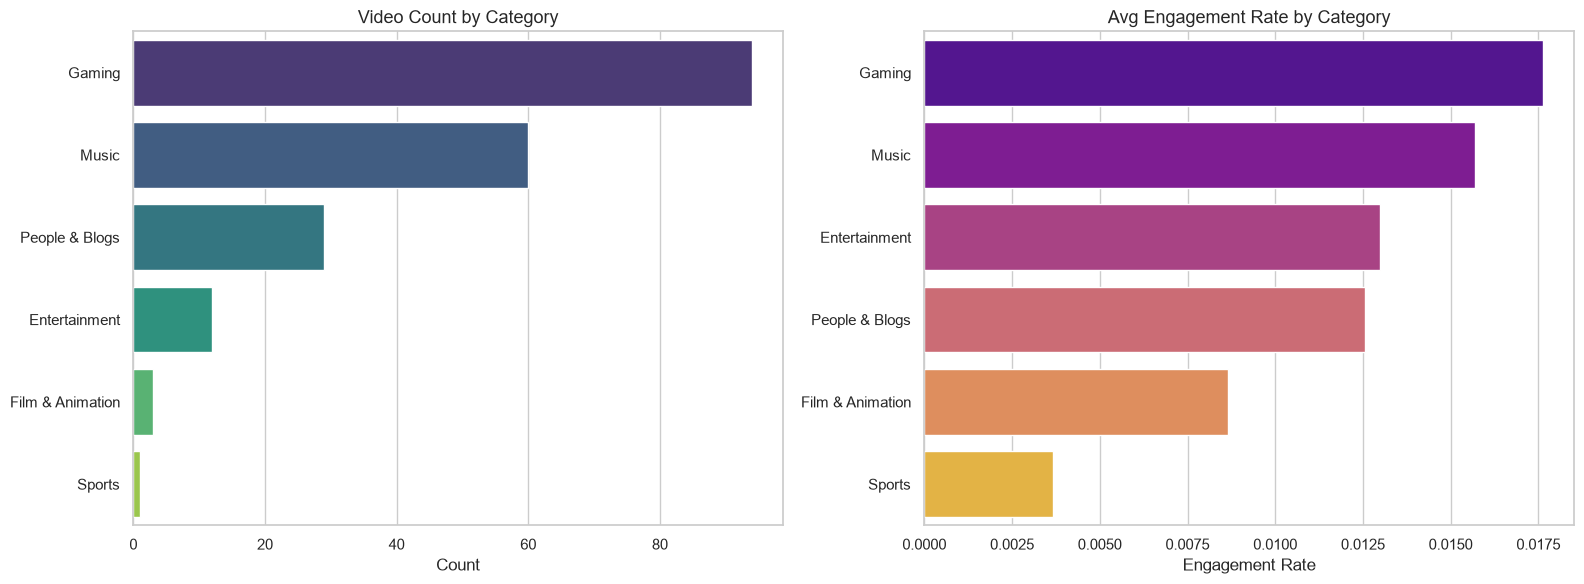

In [4]:
cat_count = df['categoryName'].value_counts().reset_index()
cat_count.columns = ['category','count']

cat_eng = (df.groupby('categoryName')['engagement_rate']
             .mean()
             .sort_values(ascending=False)
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=cat_count, x='count', y='category',
            hue='category', legend=False, palette='viridis', ax=axes[0])
axes[0].set_title('Video Count by Category')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

sns.barplot(data=cat_eng, x='engagement_rate', y='categoryName',
            hue='categoryName', legend=False, palette='plasma', ax=axes[1])
axes[1].set_title('Avg Engagement Rate by Category')
axes[1].set_xlabel('Engagement Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Duration — video dài bao lâu thì trending nhiều nhất?

Hai câu hỏi khác nhau cần trả lời cùng lúc: loại duration nào xuất hiện nhiều trong trending (volume), và loại nào kéo được view cao nhất (performance). Dùng dual-axis để thấy rõ sự chênh lệch.

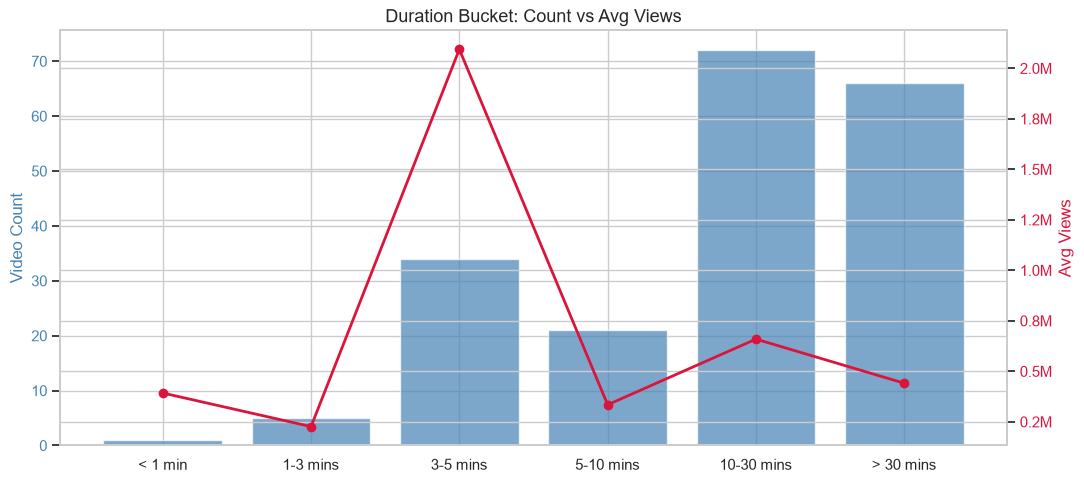

In [5]:
bucket_order = ['< 1 min','1-3 mins','3-5 mins','5-10 mins','10-30 mins','> 30 mins']

dur_count = df['duration_bucket'].value_counts().reindex(bucket_order).reset_index()
dur_count.columns = ['bucket','count']
dur_views = df.groupby('duration_bucket')['viewCount'].mean().reindex(bucket_order).reset_index()
dur_views.columns = ['bucket','avg_views']

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(dur_count['bucket'], dur_count['count'], color='steelblue', alpha=0.7)
ax1.set_ylabel('Video Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(dur_views['bucket'], dur_views['avg_views'], color='crimson', marker='o', linewidth=2)
ax2.set_ylabel('Avg Views', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax1.set_title('Duration Bucket: Count vs Avg Views')
fig.tight_layout()
plt.show()

### Timing — đăng video lúc mấy giờ thì có view cao nhất?

Publish hour ở đây đã được convert sang giờ Việt Nam. Heatmap bên dưới cho thấy pattern chi tiết hơn theo từng ngày trong tuần — có thể thấy rõ peak time của từng loại ngày.

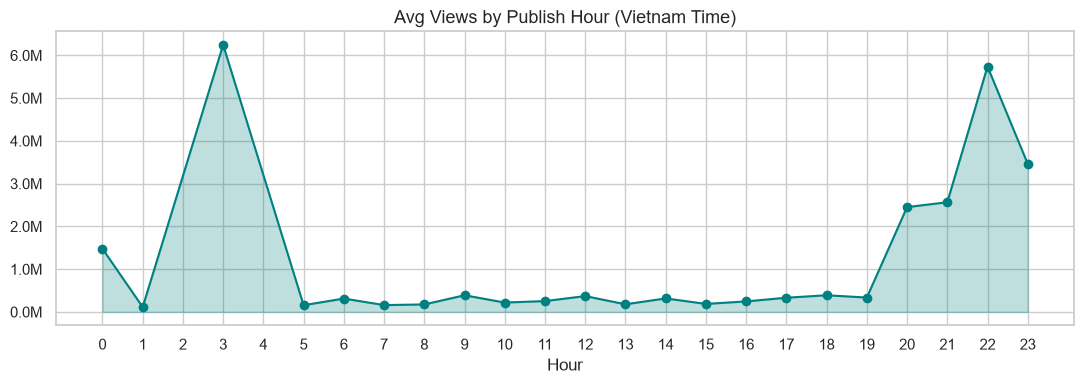

In [6]:
q_hour = df.groupby('publish_hour')['viewCount'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(q_hour['publish_hour'], q_hour['viewCount'], alpha=0.25, color='teal')
ax.plot(q_hour['publish_hour'], q_hour['viewCount'], color='teal', marker='o')
ax.set_title('Avg Views by Publish Hour (Vietnam Time)')
ax.set_xlabel('Hour')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

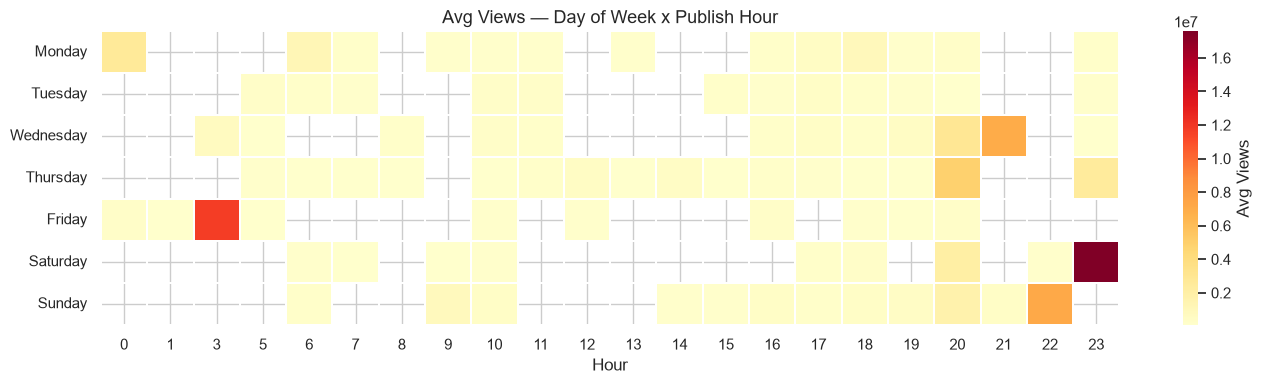

In [7]:
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.pivot_table(index='day_of_week', columns='publish_hour',
                       values='viewCount', aggfunc='mean')
pivot = pivot.reindex(days_order)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Avg Views'})
ax.set_title('Avg Views — Day of Week x Publish Hour')
ax.set_xlabel('Hour')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Title Intelligence

### Tiêu đề trending có pattern gì không?

Phân tích 3 chiều: từ khóa xuất hiện nhiều nhất (NLP), ảnh hưởng của việc dùng số/emoji, và mối quan hệ giữa độ dài tiêu đề với view. Mục tiêu không phải tìm công thức — mà xem có signal đủ mạnh để recommend không.

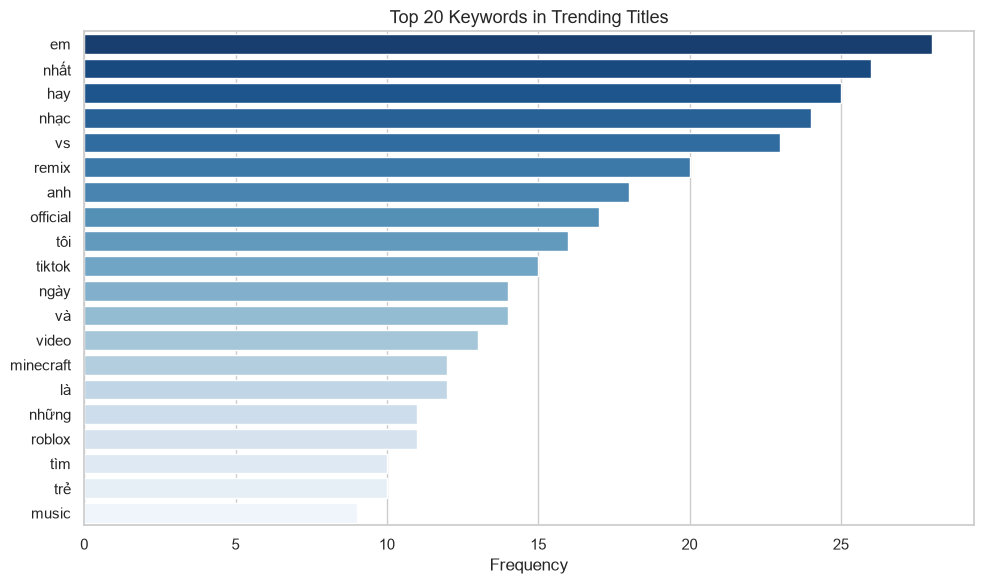

In [8]:
from underthesea import word_tokenize
from collections import Counter
import re

stopwords = {'la','va','cua','co','trong','duoc','cho','voi','khong','mot',
             'nhung','cac','khi','de','vao','tu','nay','da','nhu','lai',
             'den','o','ra','ma','bi','thi','cung','tren','nguoi','nhat'}

raw = ' '.join(df['title'].astype(str)).lower()
raw = re.sub(r'[^\w\s]', ' ', raw)
tokens = [t for t in word_tokenize(raw) if t not in stopwords and len(t) > 1 and not t.isnumeric()]

top_words = pd.DataFrame(Counter(tokens).most_common(20), columns=['word','count'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_words, x='count', y='word',
            hue='word', legend=False, palette='Blues_r', ax=ax)
ax.set_title('Top 20 Keywords in Trending Titles')
ax.set_xlabel('Frequency')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

C:\Users\bttho\AppData\Local\Temp\ipykernel_16044\1418321127.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['No','Yes'])
C:\Users\bttho\AppData\Local\Temp\ipykernel_16044\1418321127.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['No','Yes'])


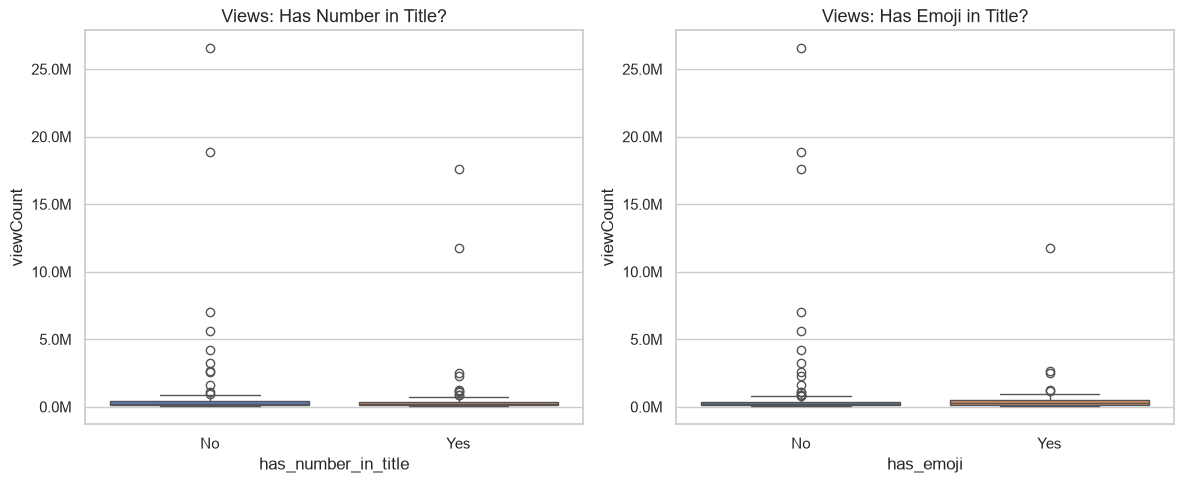

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='has_number_in_title', y='viewCount',
            hue='has_number_in_title', legend=False, ax=axes[0])
axes[0].set_title('Views: Has Number in Title?')
axes[0].set_xticklabels(['No','Yes'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

sns.boxplot(data=df, x='has_emoji', y='viewCount',
            hue='has_emoji', legend=False, ax=axes[1])
axes[1].set_title('Views: Has Emoji in Title?')
axes[1].set_xticklabels(['No','Yes'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

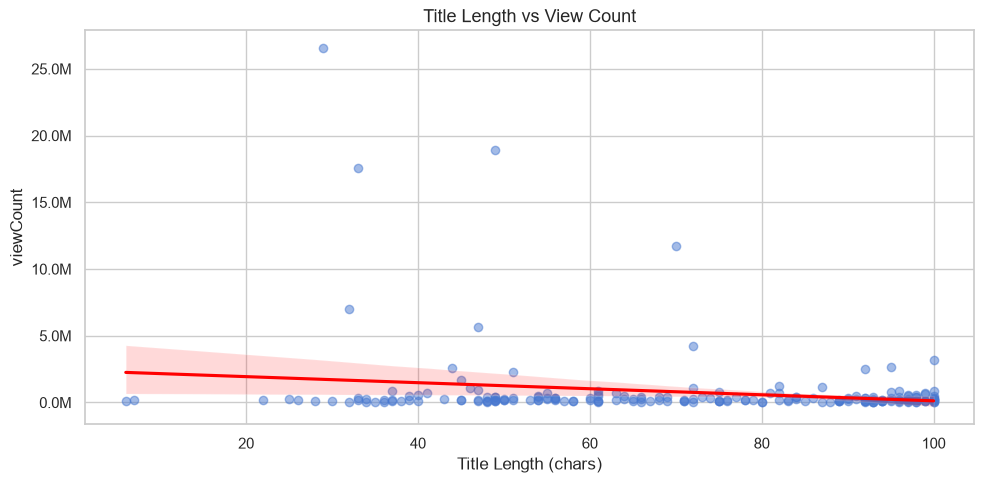

Pearson r: -0.1911


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(data=df, x='title_length', y='viewCount',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=ax)
ax.set_title('Title Length vs View Count')
ax.set_xlabel('Title Length (chars)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

r = df['title_length'].corr(df['viewCount'])
print(f'Pearson r: {r:.4f}')

## 4. Creator Intelligence

Kênh nào đang thống trị trending — và liệu kênh có nhiều video trending hơn có thực sự kéo view nhiều hơn không? Scatter plot ở phần 4.2 sẽ cho thấy nếu có correlation thật sự hay không.

C:\Users\bttho\AppData\Local\Temp\ipykernel_16044\3343004630.py:14: UserWarning: Glyph 128138 (\N{PILL}) missing from font(s) Arial.
  plt.tight_layout()
D:\Data engineering\ProjectCuoi\Youtube_analyst\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128138 (\N{PILL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


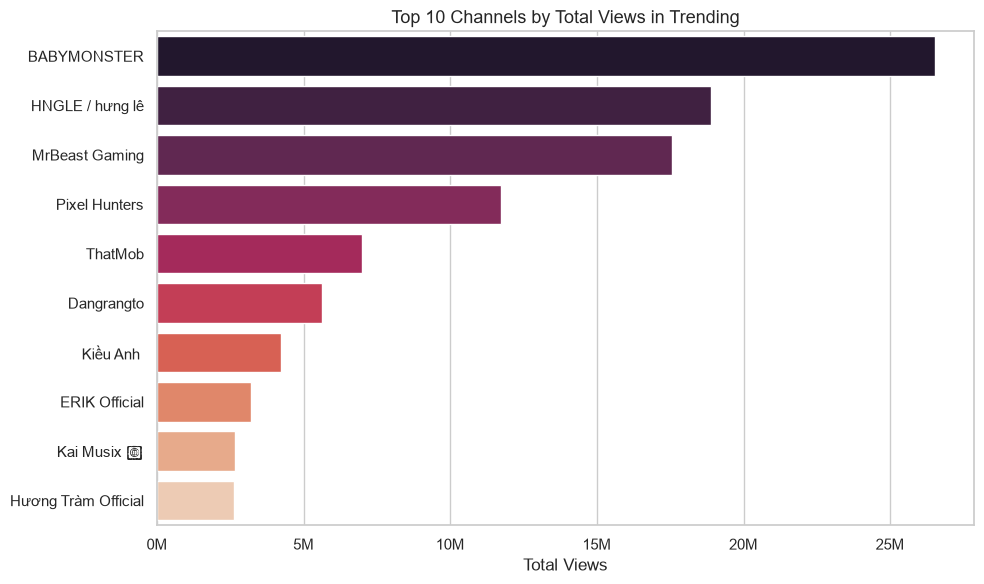

In [11]:
top_ch = (df.groupby('channelTitle')
            .agg(total_views=('viewCount','sum'), video_count=('video_id','count'))
            .sort_values('total_views', ascending=False)
            .head(10)
            .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_ch, x='total_views', y='channelTitle',
            hue='channelTitle', legend=False, palette='rocket', ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.set_title('Top 10 Channels by Total Views in Trending')
ax.set_xlabel('Total Views')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

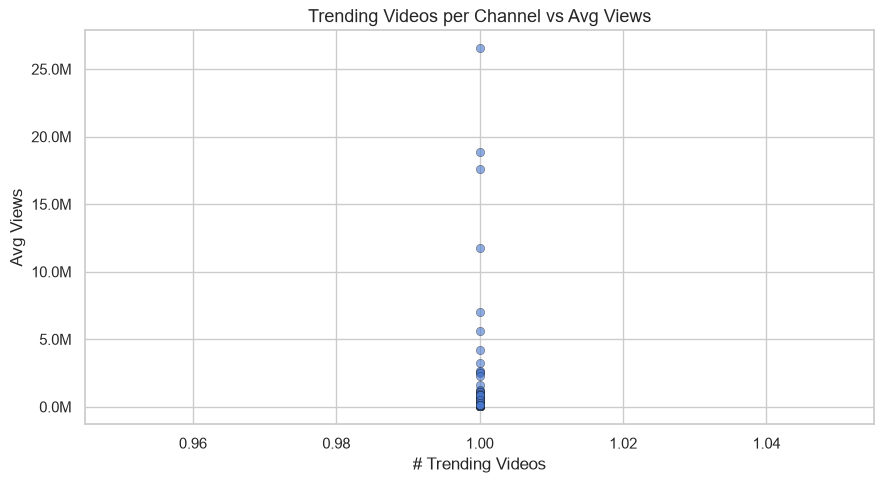

In [12]:
freq = (df.groupby('channelTitle')
          .agg(video_count=('video_id','count'), avg_views=('viewCount','mean'))
          .reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(freq['video_count'], freq['avg_views'],
           alpha=0.6, edgecolors='k', linewidths=0.4)
ax.set_title('Trending Videos per Channel vs Avg Views')
ax.set_xlabel('# Trending Videos')
ax.set_ylabel('Avg Views')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

## 5. Hashtag Analysis

Data `hashtag_performance.csv` đã được explode và aggregate từ bước clean. Mỗi row là 1 tag với tổng views, likes, comments và avg engagement rate của tất cả video sử dụng tag đó.

Scatter plot ở 5.2 thú vị hơn: tag được dùng nhiều không nhất thiết có engagement cao — màu sắc (total views) cho thấy tag nào vừa phổ biến vừa effective.

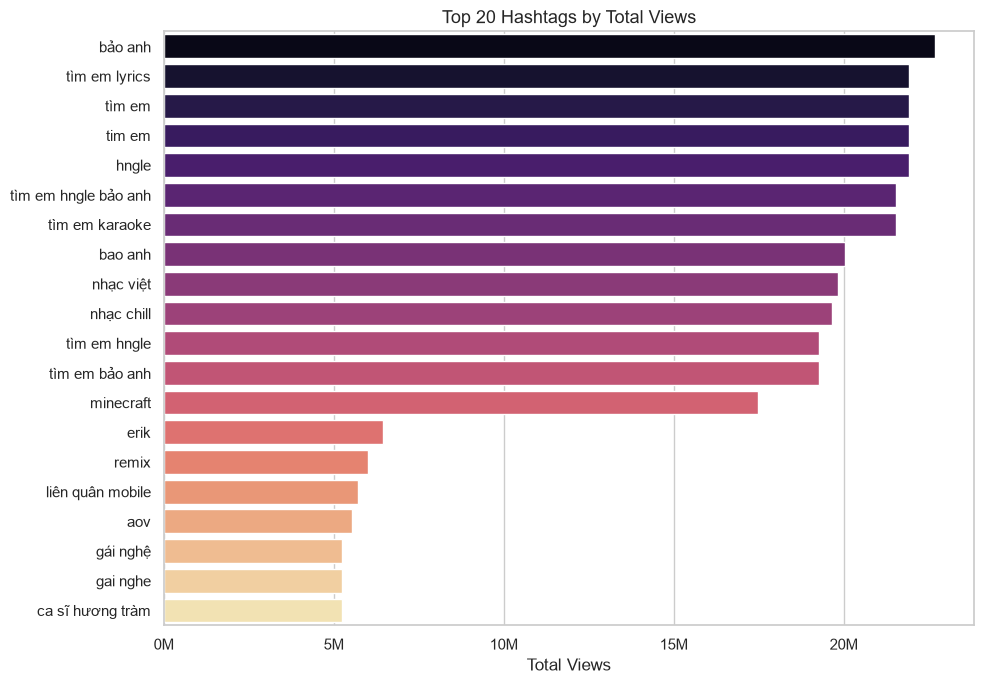

In [13]:
top20 = df_tags.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top20, x='Total_Views', y='tag',
            hue='tag', legend=False, palette='magma', ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.set_title('Top 20 Hashtags by Total Views')
ax.set_xlabel('Total Views')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

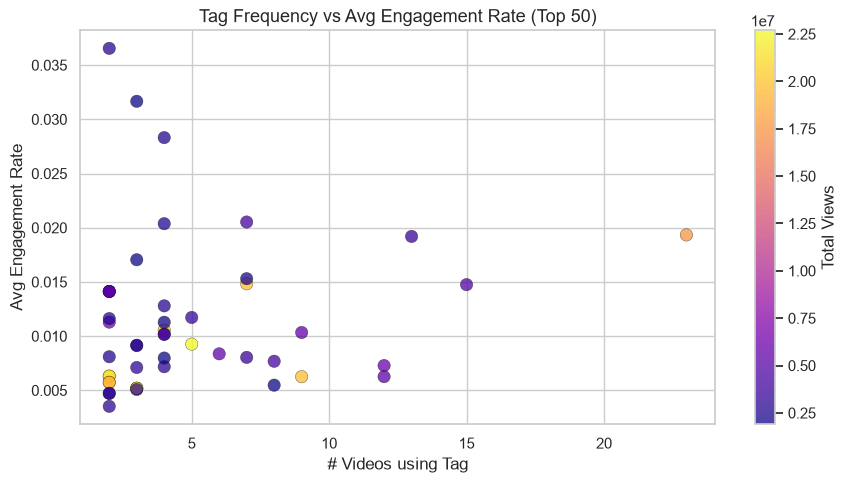

In [14]:
top50 = df_tags.head(50)

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    top50['Total_Videos'], top50['Avg_Engagement_Rate'],
    c=top50['Total_Views'], cmap='plasma',
    alpha=0.75, s=80, edgecolors='k', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='Total Views')
ax.set_title('Tag Frequency vs Avg Engagement Rate (Top 50)')
ax.set_xlabel('# Videos using Tag')
ax.set_ylabel('Avg Engagement Rate')
plt.tight_layout()
plt.show()

## 6. ANOVA — Category có ảnh hưởng đến Engagement Rate không?

Câu hỏi thực tế: nếu mình chọn làm video Gaming thay vì Music, thì engagement rate có khác biệt không?

- H₀: avg engagement rate của mọi category bằng nhau
- H₁: ít nhất 1 category khác biệt có ý nghĩa thống kê

Chỉ test các category có ít nhất 5 video để tránh nhiễu từ sample quá nhỏ.

F = 1.3196,  p = 2.6928e-01
=> fail to reject H0


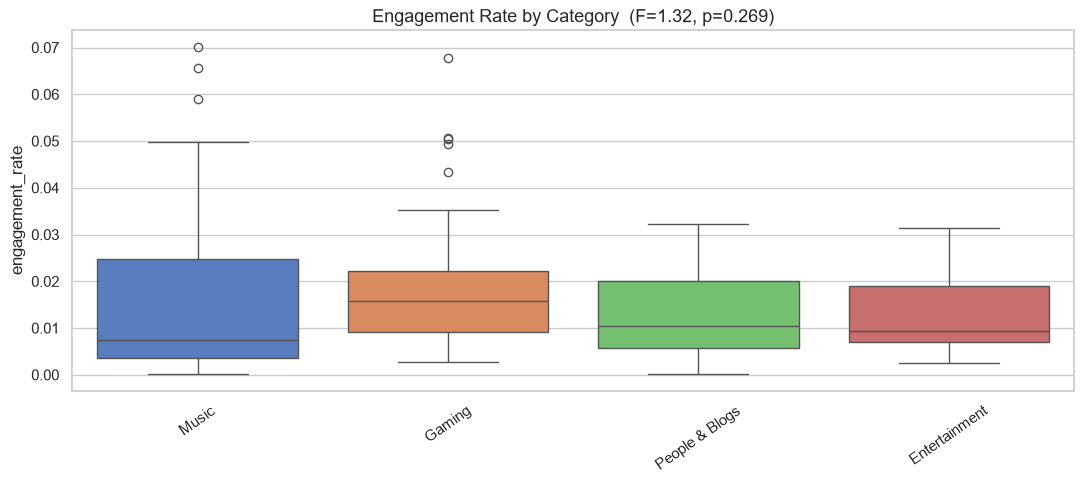

In [15]:
valid = df['categoryName'].value_counts()
valid = valid[valid >= 5].index
df_v  = df[df['categoryName'].isin(valid)]

groups = [g['engagement_rate'].values for _, g in df_v.groupby('categoryName')]
f_stat, p_val = stats.f_oneway(*groups)

print(f'F = {f_stat:.4f},  p = {p_val:.4e}')
print('=> reject H0' if p_val < 0.05 else '=> fail to reject H0')

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_v, x='categoryName', y='engagement_rate',
            hue='categoryName', legend=False, ax=ax)
ax.set_title(f'Engagement Rate by Category  (F={f_stat:.2f}, p={p_val:.3f})')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

## 7. Key Findings

| # | Finding | Actionable Insight |
|---|---------|--------------------|
| 1 | Music & Entertainment dominate in video count | Most competitive niches |
| 2 | 10–30 min videos pull the highest avg views | Long-form performs better in VN trending |
| 3 | Peak publish hours visible in line chart | Post during peak window to maximize recommendation chance |
| 4 | Low Pearson r between title length and views | Title length is not a reliable predictor |
| 5 | ANOVA p > 0.05 — category does not significantly separate engagement | Quality matters more than niche choice |
| 6 | Top hashtags cluster around music and gaming | Tag into high-traffic niches for reach |


## 8. Export to Excel

In [16]:
import importlib.util, os as _os
_spec = importlib.util.spec_from_file_location(
    'export_excel',
    _os.path.join(_os.getcwd(), '..', 'src', 'export_excel.py')
)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
_mod.create_excel_report()
print('Done.')

Done.
